In [16]:
import math 
import numpy as np 
import pandas as pd 
from datetime import date, timedelta, datetime 
from pandas.plotting import register_matplotlib_converters 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates 
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error 
from tensorflow.keras import Sequential 
from tensorflow.keras.layers import LSTM, Dense, Dropout, GRU
from tensorflow.keras.callbacks import EarlyStopping 
from sklearn.preprocessing import RobustScaler, MinMaxScaler
import seaborn as sns 
import yfinance as yf 

In [17]:
sns.set_style('white', { 'axes.spines.right': False, 'axes.spines.top': False})

end_date =  date.today().strftime("%Y-%m-%d")
start_date = '2010-01-01'

stockname = 'Apple'
symbol = 'AAPL'

df = yf.download(symbol, start=start_date, end=end_date)

df.head()

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2009-12-31,7.611786,7.619643,7.520000,7.526071,6.434925,352410800
2010-01-04,7.622500,7.660714,7.585000,7.643214,6.535085,493729600
2010-01-05,7.664286,7.699643,7.616071,7.656429,6.546382,601904800
2010-01-06,7.656429,7.686786,7.526786,7.534643,6.442254,552160000
2010-01-07,7.562500,7.571429,7.466071,7.520714,6.430345,477131200


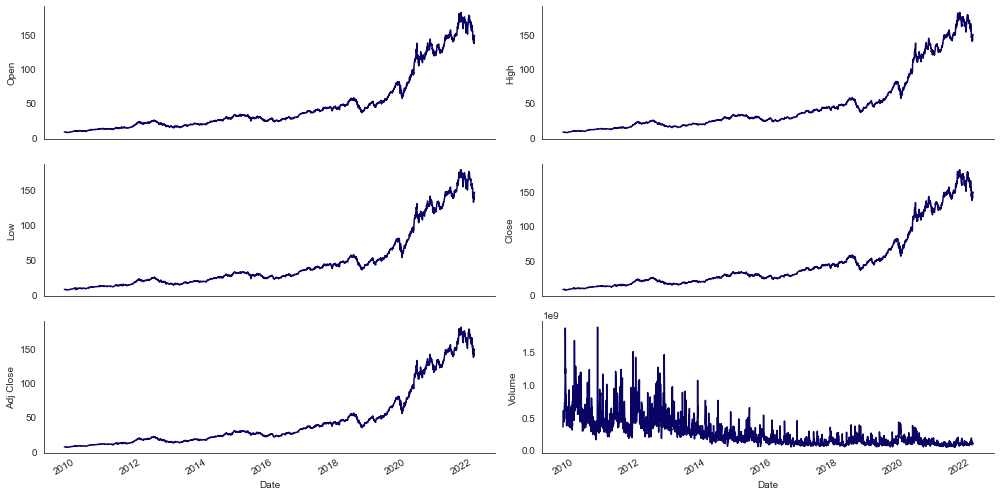

In [18]:
df_plot = df.copy()

ncols = 2
nrows = int(round(df_plot.shape[1] / ncols, 0))

fig, ax = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, figsize=(14, 7))
for i, ax in enumerate(fig.axes):
        sns.lineplot(data = df_plot.iloc[:, i], ax=ax)
        ax.tick_params(axis="x", rotation=30, labelsize=10, length=0)
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.tight_layout()
plt.show()


In [19]:

train_df = df.sort_values(by=['Date']).copy()

FEATURES = ['High', 'Low', 'Open', 'Close', 'Volume', 'Adj Close']

print('FEATURE LIST')
print([f for f in FEATURES])


data = pd.DataFrame(train_df)
data_filtered = data[FEATURES]


data_filtered_ext = data_filtered.copy()
data_filtered_ext['Prediction'] = data_filtered_ext['Close']


data_filtered_ext.tail()

FEATURE LIST
['High', 'Low', 'Open', 'Close', 'Volume', 'Adj Close']


,High,Low,Open,Close,Volume,Adj Close,Prediction
Date,,,,,,,
2022-05-24,141.970001,137.330002,140.809998,140.360001,104132700,140.360001,140.360001
2022-05-25,141.789993,138.339996,138.429993,140.520004,92482700,140.520004,140.520004
2022-05-26,144.339996,137.139999,137.389999,143.779999,90601500,143.779999,143.779999
2022-05-27,149.679993,145.259995,145.389999,149.639999,90796900,149.639999,149.639999
2022-05-31,150.660004,146.839996,149.070007,148.839996,103615600,148.839996,148.839996


In [20]:

nrows = data_filtered.shape[0]


np_data_unscaled = np.array(data_filtered)
np_data = np.reshape(np_data_unscaled, (nrows, -1))
print(np_data.shape)

scaler = MinMaxScaler()
np_data_scaled = scaler.fit_transform(np_data_unscaled)

scaler_pred = MinMaxScaler()
df_Close = pd.DataFrame(data_filtered_ext['Close'])
np_Close_scaled = scaler_pred.fit_transform(df_Close)

(3125, 6)


In [21]:

sequence_length = 50


index_Close = data.columns.get_loc("Close")

train_data_len = math.ceil(np_data_scaled.shape[0] * 0.8)


train_data = np_data_scaled[0:train_data_len, :]
test_data = np_data_scaled[train_data_len - sequence_length:, :]


def partition_dataset(sequence_length, data):
    x, y = [], []
    data_len = data.shape[0]
    for i in range(sequence_length, data_len):
        x.append(data[i-sequence_length:i,:]) 
        y.append(data[i, index_Close]) 
    
    x = np.array(x)
    y = np.array(y)
    return x, y


x_train, y_train = partition_dataset(sequence_length, train_data)
x_test, y_test = partition_dataset(sequence_length, test_data)


print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

print(x_train[1][sequence_length-1][index_Close])
print(y_train[0])

(2450, 50, 6) (2450,)
(625, 50, 6) (625,)
0.006606537962035759
0.006606537962035759


In [30]:

model = Sequential()

n_neurons = x_train.shape[1] * x_train.shape[2]
print(n_neurons, x_train.shape[1], x_train.shape[2])
model.add(LSTM(n_neurons, return_sequences=True, input_shape=(x_train.shape[1], x_train.shape[2]))) 
model.add(LSTM(n_neurons, return_sequences=False))
model.add(Dense(5, activation='relu'))
model.add(Dense(1, activation='relu'))


model.compile(optimizer='adam', loss='mse')

300 50 6


In [31]:
model.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_15 (LSTM)              (None, 50, 300)           368400    
                                                                 
 lstm_16 (LSTM)              (None, 300)               721200    
                                                                 
 dense_6 (Dense)             (None, 5)                 1505      
                                                                 
 dense_7 (Dense)             (None, 1)                 6         
                                                                 
Total params: 1,091,111
Trainable params: 1,091,111
Non-trainable params: 0
_________________________________________________________________


In [32]:
model.compile(optimizer='adam', loss='mse')

In [34]:

epochs = 50
batch_size = 16
early_stop = EarlyStopping(monitor='loss', patience=5, verbose=1)
history = model.fit(x_train, y_train, 
                    batch_size=batch_size, 
                    epochs=epochs,
                    validation_data=(x_test, y_test)
                   )

Epoch 1/50
154/154 [==============================] - ETA: 0s - loss: 0.0201

2022-06-01 17:54:10.788214: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2022-06-01 17:54:10.855423: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2022-06-01 17:54:10.924436: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


154/154 [==============================] - 6s 36ms/step - loss: 0.0201 - val_loss: 0.4854
Epoch 2/50
154/154 [==============================] - 5s 32ms/step - loss: 0.0201 - val_loss: 0.4854
Epoch 3/50
154/154 [==============================] - 5s 32ms/step - loss: 0.0201 - val_loss: 0.4854
Epoch 4/50
 79/154 [==============>...............] - ETA: 2s - loss: 0.0202

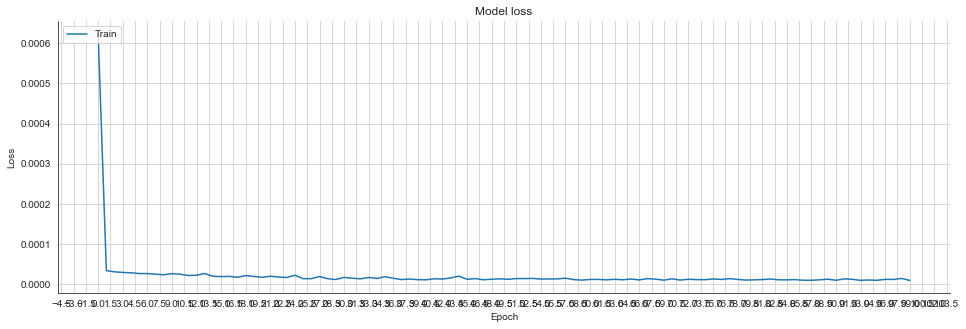

In [12]:
fig, ax = plt.subplots(figsize=(16, 5), sharex=True)
sns.lineplot(data=history.history["loss"])
plt.title("Model loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
ax.xaxis.set_major_locator(plt.MaxNLocator(epochs))
plt.legend(["Train", "Test"], loc="upper left")
plt.grid()
plt.show()

In [13]:

y_pred_scaled = model.predict(x_test)


y_pred = scaler_pred.inverse_transform(y_pred_scaled)
y_test_unscaled = scaler_pred.inverse_transform(y_test.reshape(-1, 1))


MAE = mean_absolute_error(y_test_unscaled, y_pred)
print(f'중앙값 절대 편차 (MAE): {np.round(MAE, 2)}')

MAPE = np.mean((np.abs(np.subtract(y_test_unscaled, y_pred)/ y_test_unscaled))) * 100
print(f'Mean Absolute Percentage Error (MAPE): {np.round(MAPE, 2)} %')


MDAPE = np.median((np.abs(np.subtract(y_test_unscaled, y_pred)/ y_test_unscaled)) ) * 100
print(f'Median Absolute Percentage Error (MDAPE): {np.round(MDAPE, 2)} %')

2022-06-01 17:48:17.134818: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2022-06-01 17:48:17.262254: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


 4/20 [=====>........................] - ETA: 0s 

2022-06-01 17:48:17.646811: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


20/20 [==============================] - 1s 22ms/step
Median Absolute Error (MAE): 6.86
Mean Absolute Percentage Error (MAPE): 4.93 %
Median Absolute Percentage Error (MDAPE): 4.93 %


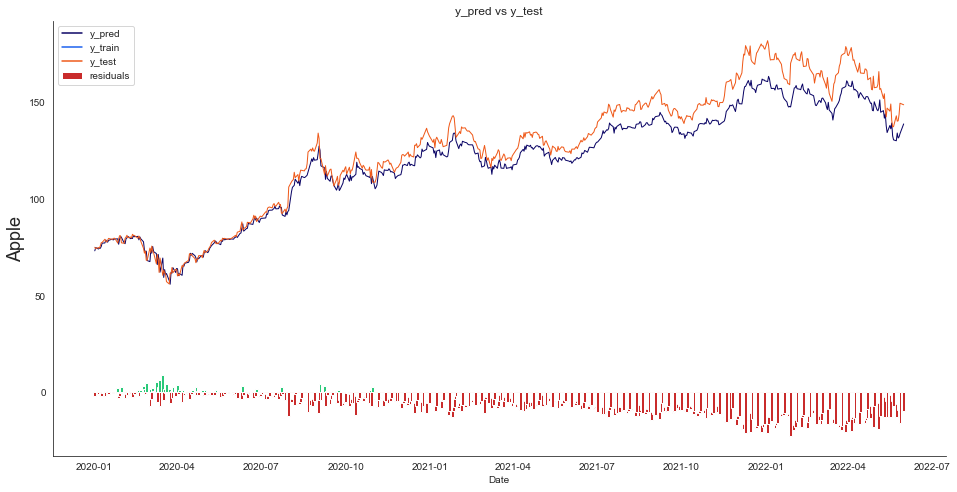

In [14]:

display_start_date = "2020-01-01" 

train = pd.DataFrame(data_filtered_ext['Close'][:train_data_len + 1]).rename(columns={'Close': 'y_train'})
valid = pd.DataFrame(data_filtered_ext['Close'][train_data_len:]).rename(columns={'Close': 'y_test'})
valid.insert(1, "y_pred", y_pred, True)
valid.insert(1, "residuals", valid["y_pred"] - valid["y_test"], True)
df_union = pd.concat([train, valid])

df_union_zoom = df_union[df_union.index > display_start_date]

fig, ax1 = plt.subplots(figsize=(16, 8))
plt.title("y_pred vs y_test")
plt.ylabel(stockname, fontsize=18)
sns.set_palette(["#090364", "#1960EF", "#EF5919"])
sns.lineplot(data=df_union_zoom[['y_pred', 'y_train', 'y_test']], linewidth=1.0, dashes=False, ax=ax1)

df_sub = ["#2BC97A" if x > 0 else "#C92B2B" for x in df_union_zoom["residuals"].dropna()]
ax1.bar(height=df_union_zoom['residuals'].dropna(), x=df_union_zoom['residuals'].dropna().index, width=3, label='residuals', color=df_sub)
plt.legend()
plt.show()

In [15]:
df_temp = df[-sequence_length:]
new_df = df_temp.filter(FEATURES)

N = sequence_length

last_N_days = new_df[-sequence_length:].values
last_N_days_scaled = scaler.transform(last_N_days)

X_test_new = []
X_test_new.append(last_N_days_scaled)

pred_price_scaled = model.predict(np.array(X_test_new))
pred_price_unscaled = scaler_pred.inverse_transform(pred_price_scaled.reshape(-1, 1))

price_today = np.round(new_df['Close'][-1], 2)
predicted_price = np.round(pred_price_unscaled.ravel()[0], 2)
change_percent = np.round(100 - (price_today * 100)/predicted_price, 2)

plus = '+'; minus = ''
print(f'{end_date} {stockname}의 가격은 {price_today}입니다.')
print(f'{stockname}의 예상 주가는 {predicted_price}이고 ({plus if change_percent > 0 else minus}{change_percent}% 변동될 것으로 예상됩니다.)')

1/1 [==============================] - 0s 154ms/step
2022-06-01 Apple의 가격은 148.84입니다.
Apple의 예상 주가는 138.25999450683594이고 (-7.65% 변동될 것으로 예상됩니다.)
